In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

In [5]:
# Open the timeseries file
ds = xr.open_dataset('sg175_2026_07_17_TasmanX_test_timeseries.nc')
display(ds)

# Check the first time to see if an offset is needed
ds.time.values[0]

<xarray.Dataset> Size: 164kB
Dimensions:                                   (gps_info: 15,
                                               sg_data_point: 875, dive: 5,
                                               trajectory: 5)
Coordinates:
    ctd_time                                  (sg_data_point) datetime64[ns] 7kB ...
    ctd_depth                                 (sg_data_point) float32 4kB ...
    latitude                                  (sg_data_point) float32 4kB ...
    longitude                                 (sg_data_point) float32 4kB ...
  * trajectory                                (trajectory) int32 20B 1 2 3 4 5
Dimensions without coordinates: gps_info, sg_data_point, dive
Data variables: (12/67)
    gps_info_dive_number                      (gps_info) int32 60B ...
    sg_data_point_dive_number                 (sg_data_point) int32 4kB ...
    log_gps_time                              (gps_info) datetime64[ns] 120B ...
    time                                      (sg_data_point) datetime64[ns] 7kB ...
    pressure                                  (sg_data_point) float32 4kB ...
    depth                                     (sg_data_point) float32 4kB ...
    ...                                        ...
    end_longitude                             (dive) float32 20B ...
    depth_avg_curr_east                       (dive) float32 20B ...
    depth_avg_curr_north                      (dive) float32 20B ...
    depth_avg_curr_qc                         (dive) |S1 5B ...
    latlong_qc                                (dive) |S1 5B ...
    glider                                    |S12 12B ...
Attributes: (12/47)
    project:                         2026_07_17_TasmanX_test
    title:                           Physical, chemical, and biological data ...
    summary:                         SG175 2026_07_17_TasmanX_test
    source:                          Seaglider SG175
    references:                      http://data.nodc.noaa.gov/accession/0092291
    processing_level:                1.12
    ...                              ...
    date_modified:                   2026-08-12T22:35:45Z
    uuid:                            289e8928-969e-11f1-a797-974ad7389db0
    base_station_version:            3.0.9
    base_station_micro_version:      0
    quality_control_version:         1.12
    Conventions:                     CF-1.6

np.datetime64('2026-07-17T15:24:56.171000064')

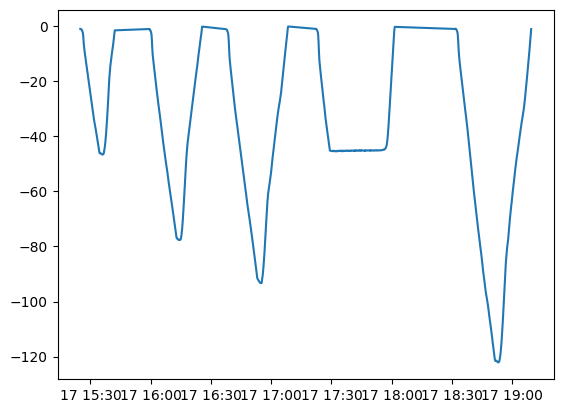

In [6]:
# Check the depth to see if an offset is needed
depth = ds.depth.values
time = ds.time.values
plt.plot(time, -depth)

# Is depth above 0? Is a linear or variable offset needed? If linear, add a value to all depth values

In [ ]:
# SG Data Point Files

# Make sure you are where you want to be
print(os.getcwd())

# Rename variables for clarity
ds['PAR_470nm'] = ds['eng_wlbb2fl_sig470nm']
ds['particle_concentration_700nm'] = ds['eng_wlbb2fl_sig700nm']
ds['chlorophyll_695nm'] = ds['eng_wlbb2fl_sig695nm']
ds['dissolved_oxygen'] = ds['aanderaa4330_dissolved_oxygen']
ds['instrument_dissolved_oxygen'] = ds['aanderaa4330_instrument_dissolved_oxygen']

# Add metadata
ds['PAR_470nm'].attrs['pre_cleaning_name'] = 'eng_wlbb2fl_sig470nm'
ds['particle_concentration_700nm'].attrs['pre_cleaning_name'] = 'eng_wlbb2fl_sig700nm'
ds['chlorophyll_695nm'].attrs['pre_cleaning_name'] = 'eng_wlbb2fl_sig695nm'
ds['dissolved_oxygen'].attrs['pre_cleaning_name'] = 'aanderaa4330_dissolved_oxygen'
ds['instrument_dissolved_oxygen'].attrs['pre_cleaning_name'] = 'aanderaa4330_instrument_dissolved_oxygen'

# Select the relevant variables (depth_corrected if correction applied, just depth if not)
new_ds = ds[['time', 'depth', 'latitude', 'longitude','temperature', 'salinity', 'dissolved_oxygen', 'instrument_dissolved_oxygen', 'PAR_470nm', 'particle_concentration_700nm', 'chlorophyll_695nm']]

# Convert to DataFrame and save as csv and nc 
new_ds.to_dataframe().reset_index().to_csv('cleaned_sg175_shilshole_test_timeseries.csv', index=False)
new_ds.to_netcdf('newfilename.nc')
display(new_ds)

In [ ]:
# Depth Average Currents Files

# Did you apply a time offset before? If so, apply the same one here
adjusted_start = pd.to_datetime(ds['start_time'].values) + pd.DateOffset(years=, months=, days=)
adjusted_end = pd.to_datetime(ds['end_time'].values) + pd.DateOffset(years=, months=, days=)
ds = ds.assign_coords(start_time=('dive', adjusted_start), end_time=('dive', adjusted_end))

# Rename variables for clarity
ds['U_DAC'] = ds['depth_avg_curr_east']
ds['V_DAC'] = ds['depth_avg_curr_north']

# Add metadata
ds['U_DAC'].attrs['pre_cleaning_name'] = 'depth_avg_curr_east'
ds['V_DAC'].attrs['pre_cleaning_name'] = 'depth_avg_curr_north'

# Select the relevant variables
new_ds = ds[['U_DAC', 'V_DAC', 'start_time', 'end_time', 'start_latitude', 'end_latitude', 'start_longitude', 'end_longitude', 'dive_number']]
display(new_ds)

# Convert to DataFrame and save as csv and nc 
new_ds.to_dataframe().reset_index().to_csv('DAC_newfilename.csv', index=False)
new_ds.to_netcdf('DAC_newfilename.nc')
